In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!ls /kaggle/input

datasets


# Imports 

In [3]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import torchvision.transforms.v2 as v2
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from tqdm import tqdm

# Load the data  

In [4]:
COCO_ROOT     = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
TRAIN_IMG_DIR = os.path.join(COCO_ROOT, "train2017")
# VAL_IMG_DIR et TEST_IMG_DIR supprimés → on split depuis train2017

IMG_SIZE    = 256
BATCH_SIZE  = 32
NUM_WORKERS = 2
SEED        = 42
EPOCHS      =30
PATIENCE    = 5

MAX_TRAIN_IMAGES = 7000
MAX_VAL_IMAGES   = 500
MAX_TEST_IMAGES  = 500
TOTAL_IMAGES     = MAX_TRAIN_IMAGES + MAX_VAL_IMAGES + MAX_TEST_IMAGES  # 7000

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

Device : cuda


## Transforms

In [5]:
color_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

gray_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.Grayscale(num_output_channels=1),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

## — Dataset

In [6]:
class COCOColorizationDataset(Dataset):
    """
    x  = image N&B  1 canal  (input  générateur)
    y  = image RGB  3 canaux (target générateur)
    """
    def __init__(self, img_dir, color_tfm=None, gray_tfm=None, max_images=None):
        self.img_dir   = img_dir
        self.color_tfm = color_tfm
        self.gray_tfm  = gray_tfm
        self.img_files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        if max_images is not None and len(self.img_files) > max_images:
            self.img_files = self.img_files[:max_images]
        print(f"  Dossier '{os.path.basename(img_dir)}' : {len(self.img_files)} images")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        path    = os.path.join(self.img_dir, self.img_files[idx])
        img_rgb = Image.open(path).convert("RGB")
        x = self.gray_tfm(img_rgb)  if self.gray_tfm  else img_rgb
        y = self.color_tfm(img_rgb) if self.color_tfm else img_rgb
        return x, y

# ---- Chargement depuis train2017 uniquement ----
print("\nChargement des datasets :")
full_dataset = COCOColorizationDataset(
    TRAIN_IMG_DIR, color_transform, gray_transform,
    max_images=TOTAL_IMAGES
)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [MAX_TRAIN_IMAGES, MAX_VAL_IMAGES, MAX_TEST_IMAGES],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"  ✅ Train : {len(train_dataset)} images")
print(f"  ✅ Val   : {len(val_dataset)} images")
print(f"  ✅ Test  : {len(test_dataset)} images")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Vérification batch
x_b, y_b = next(iter(train_loader))
print(f"\nBatch  x (N&B)     : {x_b.shape}  [{x_b.min():.2f}, {x_b.max():.2f}]")
print(f"Batch  y (couleur) : {y_b.shape}  [{y_b.min():.2f}, {y_b.max():.2f}]")


Chargement des datasets :
  Dossier 'train2017' : 8000 images
  ✅ Train : 7000 images
  ✅ Val   : 500 images
  ✅ Test  : 500 images

Batch  x (N&B)     : torch.Size([32, 1, 256, 256])  [-1.00, 1.00]
Batch  y (couleur) : torch.Size([32, 3, 256, 256])  [-1.00, 1.00]


##  Visualisation

/tmp/ipykernel_23/560996807.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


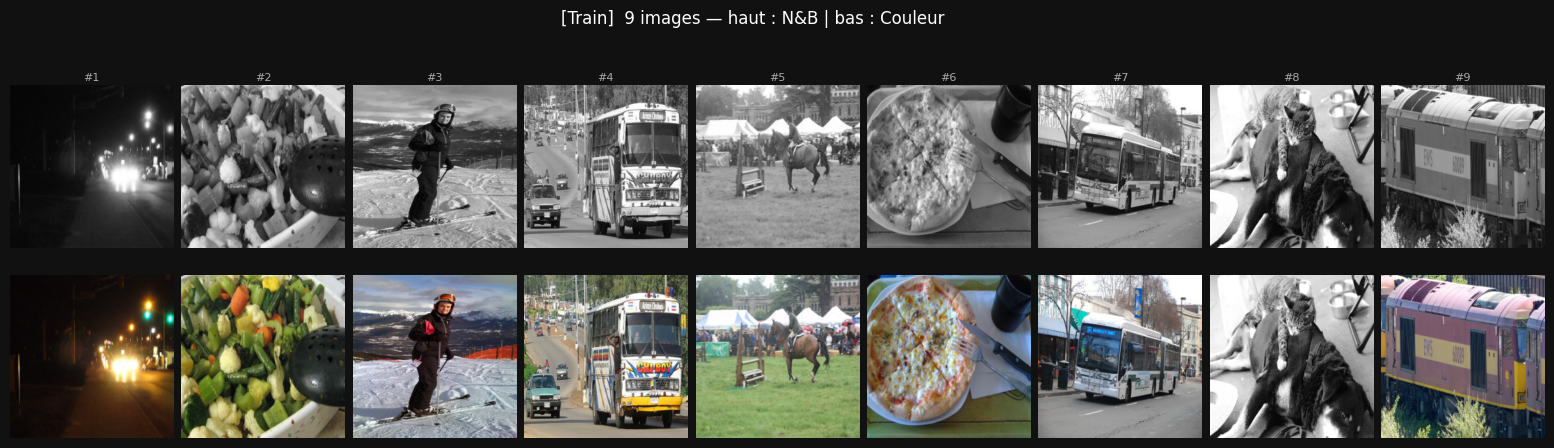

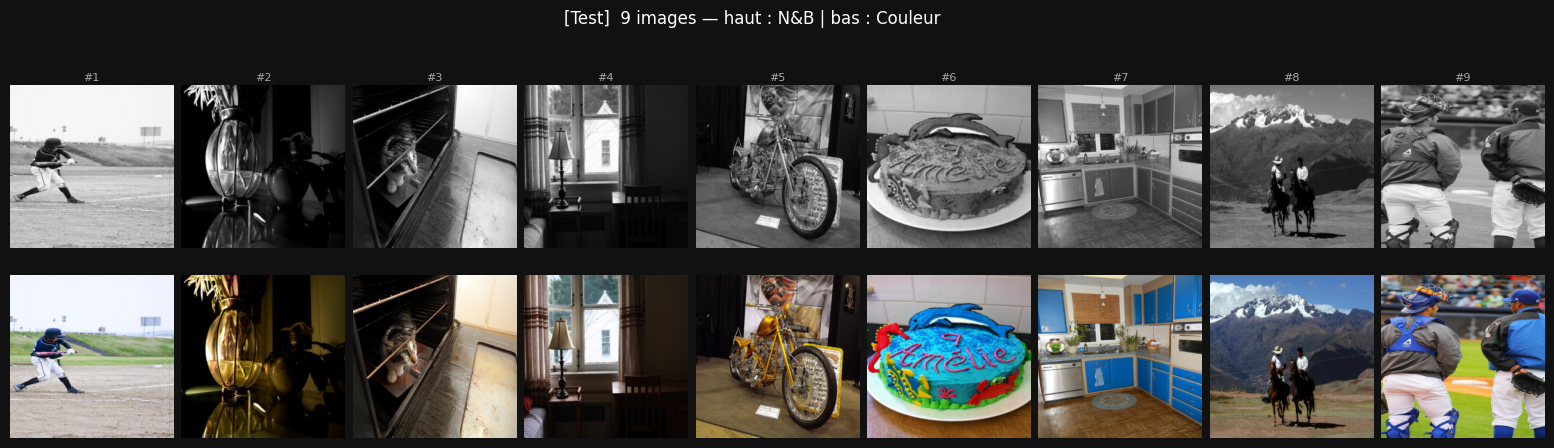

In [7]:
def denorm(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)
 
def tensor_to_img(t):
    """Tensor (C,H,W) → numpy (H,W,C) ou (H,W) si 1 canal"""
    t = denorm(t).cpu()
    if t.shape[0] == 1:
        return t.squeeze(0).numpy()   # grayscale
    return t.permute(1, 2, 0).numpy()
 
def show_samples(loader, split_name="Train", n_images=9):
    x_batch, y_batch = next(iter(loader))
    n = min(n_images, x_batch.size(0))
    fig, axes = plt.subplots(2, n, figsize=(n * 2.2, 2 * 2.4),
                             gridspec_kw={"hspace": 0.06, "wspace": 0.05})
    fig.patch.set_facecolor("#111111")
    for col in range(n):
        ax = axes[0][col]
        ax.imshow(tensor_to_img(x_batch[col]), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(f"#{col+1}", color="#aaaaaa", fontsize=8, pad=3)
        if col == 0:
            ax.set_ylabel("N&B  (input)", color="white", fontsize=9, labelpad=6)
        ax = axes[1][col]
        ax.imshow(tensor_to_img(y_batch[col]))
        ax.axis("off")
        if col == 0:
            ax.set_ylabel("Couleur  (target)", color="white", fontsize=9, labelpad=6)
    fig.suptitle(f"[{split_name}]  {n} images — haut : N&B | bas : Couleur",
                 color="white", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"samples_{split_name.lower()}.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
 
show_samples(train_loader, "Train", n_images=9)
show_samples(test_loader,  "Test",  n_images=9)

## CGAN Archetecture

In [8]:
# ================================================================
# Cellule 6 — Architecture CGAN (VERSION CORRIGÉE)
# ================================================================

class ConvNormAct2d(nn.Module):
    """Encodeur : Conv stride=2 + BN + LeakyReLU"""
    def __init__(self, in_chan, out_chan):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_chan, out_chan, 4, 2, 1),
            nn.BatchNorm2d(out_chan),
            nn.LeakyReLU(0.2),
        )
    def forward(self, x):
        return self.model(x)

class ConvTransNormAct2d(nn.Module):
    """Décodeur : ConvTranspose stride=2 + BN + GELU"""
    def __init__(self, in_chan, out_chan):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_chan, out_chan, 4, 2, 1),
            nn.BatchNorm2d(out_chan),
            nn.GELU(),
        )
    def forward(self, x):
        return self.model(x)

# ---- Encodeur ----
class Encoder(nn.Module):
    def __init__(self, img_chan, n_chans):
        super().__init__()
        stem = nn.Sequential(
            nn.Conv2d(img_chan, n_chans[0], 5, 1, 2),
            nn.LeakyReLU(0.2),
        )
        layers = [stem]
        # Créer les couches de downsampling
        for i in range(len(n_chans) - 1):
            in_c = n_chans[i]
            out_c = n_chans[i + 1]
            layers.append(ConvNormAct2d(in_c, out_c))
        self.model = nn.ModuleList(layers)
        self.n_chans = n_chans

    def forward(self, x):
        state = []
        h = x
        for layer in self.model:
            h = layer(h)
            state.append(h)
        # Retourner les skip connections (sans la dernière)
        return h, list(reversed(state[:-1]))

# ---- Décodeur ----
class Decoder(nn.Module):
    def __init__(self, n_chans):
        super().__init__()
        layers = []
        for i in range(len(n_chans) - 1):
            # ✅ CORRECTION : la 1ère couche (i=0) pas de *2, les suivantes oui
            in_c = n_chans[i] if i == 0 else n_chans[i] * 2
            out_c = n_chans[i + 1]
            layers.append(ConvTransNormAct2d(in_c, out_c))
        self.model = nn.ModuleList(layers)
        self.out_conv = nn.Sequential(
            nn.Conv2d(n_chans[-1], 3, 1),
            nn.Tanh(),
        )
        self.n_chans = n_chans

    def forward(self, x, state):
        h = x
        for i, layer in enumerate(self.model):
            if i > 0 and (i - 1) < len(state):
                h = torch.cat([state[i - 1], h], dim=1)
            h = layer(h)
        return self.out_conv(h)
# ---- UNet Générateur ----
class UNet(nn.Module):
    def __init__(self, enc_chans, dec_chans):
        super().__init__()
        self.encoder = Encoder(1, enc_chans)
        self.decoder = Decoder(dec_chans)

    def forward(self, x):
        h, state = self.encoder(x)
        return self.decoder(h, state)

# ---- Discriminateur PatchGAN ----
class Discriminator(nn.Module):
    def __init__(self, enc_chans):
        super().__init__()
        self.encoder = Encoder(4, enc_chans)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(enc_chans[-1], 1),
            nn.Sigmoid()
        )

    def forward(self, gray, rgb):
        x = torch.cat([gray, rgb], dim=1)
        h, _ = self.encoder(x)
        return self.classifier(h)

# ---- Configuration des canaux (CORRIGÉE) ----
# Les deux listes doivent avoir la même longueur
enc_chans = [64, 128, 256, 512, 512]          # 5 couches encodeur
dec_chans_corrected = list(reversed(enc_chans))  # [512, 512, 256, 128, 64]

# Test dimensionnel
_gen  = UNet(enc_chans, dec_chans_corrected)
_disc = Discriminator(enc_chans)
_x = torch.ones(1, 1, IMG_SIZE, IMG_SIZE)
_y = _gen(_x)
print(f"\n✅ Générateur  params : {sum(p.numel() for p in _gen.parameters()):,}")
print(f"✅ Générateur  output : {_y.shape}")
print(f"✅ Discrim.    params : {sum(p.numel() for p in _disc.parameters()):,}")
print(f"✅ Discrim.    output : {_disc(_x, _y).shape}")
del _gen, _disc, _x, _y


✅ Générateur  params : 16,655,107
✅ Générateur  output : torch.Size([1, 3, 256, 256])
✅ Discrim.    params : 6,958,017
✅ Discrim.    output : torch.Size([1, 1])


In [9]:
class ConvNeXtPerceptualLoss(nn.Module):
    def __init__(self, device, layers=None):
        super().__init__()
        self.use_loss = False
        if self.use_loss:
            convnext = models.convnext_tiny(weights="DEFAULT").features.to(device).eval()
            for p in convnext.parameters():
                p.requires_grad = False
            self.layers = layers if layers is not None else [0, 1, 2, 3, 4]
            self.selected_layers = nn.ModuleList([convnext[i] for i in self.layers])

    def forward(self, x, y):
        if not self.use_loss:
            return torch.tensor(0.0, device=x.device)
        loss = 0.0
        for layer in self.selected_layers:
            x = layer(x)
            y = layer(y)
            loss += nn.functional.l1_loss(x, y)
        return loss


class CGAN(nn.Module):
    def __init__(self, enc_chans, dec_chans,
                 lr_g=2e-4, lr_d=2e-4,
                 lambda_perc=0.0):
        super().__init__()
        self.device      = DEVICE
        self.lambda_perc = lambda_perc

        self.generator     = nn.DataParallel(UNet(enc_chans, dec_chans)).to(self.device)
        self.discriminator = nn.DataParallel(Discriminator(enc_chans)).to(self.device)

        self.bce_loss  = nn.BCELoss()
        self.l1_loss   = nn.L1Loss()
        self.perc_loss = ConvNeXtPerceptualLoss(device=self.device)

        self.opt_G = torch.optim.AdamW(self.generator.parameters(),
                                        lr=lr_g, betas=(0.5, 0.999))
        self.opt_D = torch.optim.AdamW(self.discriminator.parameters(),
                                        lr=lr_d, betas=(0.5, 0.999))

        self.sched_G = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.opt_G, patience=5, min_lr=1e-6, factor=0.2)
        self.sched_D = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.opt_D, patience=5, min_lr=1e-6, factor=0.2)

    def _prepare(self, x, y):
        self.gray  = x.to(self.device)
        self.rgb   = y.to(self.device)
        B          = x.size(0)
        # ✅ CORRECTION : shape (B,) au lieu de (B,1) pour compatibilité DataParallel
        self.ones  = torch.ones (B, device=self.device)
        self.zeros = torch.zeros(B, device=self.device)

    def _forward_G(self):
        self.rgb_hat = self.generator(self.gray)

    def _update_D(self):
        self.opt_D.zero_grad()
        # ✅ CORRECTION : .view(-1) pour aplatir la sortie du discriminateur
        real_score = self.discriminator(self.gray, self.rgb).view(-1)
        fake_score = self.discriminator(self.gray, self.rgb_hat.detach()).view(-1)
        loss_D = (self.bce_loss(real_score, self.ones) +
                  self.bce_loss(fake_score, self.zeros)) / 2
        loss_D.backward()
        self.opt_D.step()
        return loss_D.item()

    def _update_G(self):
        self.opt_G.zero_grad()
        # ✅ CORRECTION : .view(-1) ici aussi
        fake_score = self.discriminator(self.gray, self.rgb_hat).view(-1)
        loss_adv  = self.bce_loss(fake_score, self.ones)
        loss_perc = self.perc_loss(self.rgb_hat, self.rgb) * self.lambda_perc
        loss_l1   = self.l1_loss(self.rgb_hat, self.rgb) * 10
        loss_G = loss_adv + loss_perc + loss_l1
        loss_G.backward()
        self.opt_G.step()
        return loss_G.item()

    def optimize(self, x, y):
        self._prepare(x, y)
        self.generator.train()
        self.discriminator.train()
        self._forward_G()
        loss_D = self._update_D()
        loss_G = self._update_G()
        return loss_D, loss_G

    def evaluate(self, x, y):
        self._prepare(x, y)
        self.generator.eval()
        self.discriminator.eval()
        with torch.no_grad():
            self._forward_G()
            # ✅ CORRECTION : .view(-1) sur tous les scores
            real_score = self.discriminator(self.gray, self.rgb).view(-1)
            fake_score = self.discriminator(self.gray, self.rgb_hat).view(-1)
            loss_D = (self.bce_loss(real_score, self.ones) +
                      self.bce_loss(fake_score, self.zeros)).item() / 2
            loss_G = (self.bce_loss(fake_score, self.ones) +
                      self.perc_loss(self.rgb_hat, self.rgb) * self.lambda_perc +
                      self.l1_loss(self.rgb_hat, self.rgb) * 10).item()
        return loss_D, loss_G

    def predict(self, x):
        self.generator.eval()
        with torch.no_grad():
            return self.generator(x.to(self.device))

In [10]:
class Trainer:
    def __init__(self, model: CGAN):
        self.model   = model
        self.history = {"losses_D": [], "val_losses_D": [],
                        "losses_G": [], "val_losses_G": []}

    def _train_step(self, loader, verbose):
        total_D = total_G = 0
        it = tqdm(loader, desc="  Train") if verbose else loader
        for x, y in it:
            d, g = self.model.optimize(x, y)
            total_D += d
            total_G += g
            if verbose:
                it.set_postfix({"loss_D": f"{d:.4f}", "loss_G": f"{g:.4f}"})
        n = len(loader)
        self.history["losses_D"].append(total_D / n)
        self.history["losses_G"].append(total_G / n)

    def _eval_step(self, loader, verbose):
        total_D = total_G = 0
        it = tqdm(loader, desc="  Val  ") if verbose else loader
        for x, y in it:
            d, g = self.model.evaluate(x, y)
            total_D += d
            total_G += g
            if verbose:
                it.set_postfix({"val_D": f"{d:.4f}", "val_G": f"{g:.4f}"})
        n = len(loader)
        self.history["val_losses_D"].append(total_D / n)
        self.history["val_losses_G"].append(total_G / n)

    def fit(self, train_loader, val_loader,
            epochs=50, verbose=True, patience=10):
        best_loss  = float("inf")
        best_state = None
        no_improve = 0

        try:
            for epoch in range(1, epochs + 1):
                print(f"\nÉpoque {epoch}/{epochs}")
                self._train_step(train_loader, verbose)
                self._eval_step(val_loader,   verbose)

                vg = self.history["val_losses_G"][-1]
                vd = self.history["val_losses_D"][-1]
                self.model.sched_G.step(vg)
                self.model.sched_D.step(vd)

                print(f"  → train_G={self.history['losses_G'][-1]:.4f} "
                      f"train_D={self.history['losses_D'][-1]:.4f} "
                      f"val_G={vg:.4f}  val_D={vd:.4f}")

                if vg < best_loss - 1e-6:
                    best_loss  = vg
                    best_state = {k: v.cpu().clone()
                                  for k, v in self.model.state_dict().items()}
                    no_improve = 0
                    print(f"  ✓ Meilleure val_G : {best_loss:.4f}  (sauvegardée)")
                    torch.save(best_state, "best_cgan.pth")
                else:
                    no_improve += 1
                    print(f"  Pas d'amélioration ({no_improve}/{patience})")
                    if no_improve >= patience:
                        print("  Early stopping !")
                        break

        except KeyboardInterrupt:
            print("\nInterrompu.")
        finally:
            if best_state is not None:
                self.model.load_state_dict(best_state)
                print(f"Meilleur état rechargé (val_G = {best_loss:.4f})")

    def plot_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        for ax, key, title in [
            (ax1, "G", "Perte Générateur"),
            (ax2, "D", "Perte Discriminateur"),
        ]:
            ax.plot(self.history[f"losses_{key}"], label="Train")
            ax.plot(self.history[f"val_losses_{key}"], label="Val")
            ax.set_title(title)
            ax.set_xlabel("Époque")
            ax.legend()
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig("training_curves.png", dpi=150)
        plt.show()

    def predict(self, loader):
        # ✅ CORRECTION : mode eval explicite sur tout le modèle
        self.model.generator.eval()
        self.model.discriminator.eval()
        preds = []
        with torch.no_grad():
            for x, _ in loader:
                preds.append(self.model.predict(x).cpu().numpy())
        return np.concatenate(preds, axis=0)


Époque 1/30


  Val  : 100%|██████████| 16/16 [00:07<00:00,  2.00it/s, val_D=0.6546, val_G=1.9772]


  → train_G=2.4431 train_D=0.6159 val_G=2.1830  val_D=0.6548
  ✓ Meilleure val_G : 2.1830  (sauvegardée)

Époque 2/30


  Val  : 100%|██████████| 16/16 [00:07<00:00,  2.09it/s, val_D=0.7209, val_G=1.9198]


  → train_G=2.4115 train_D=0.6244 val_G=2.0131  val_D=0.7110
  ✓ Meilleure val_G : 2.0131  (sauvegardée)

Époque 3/30


...

  → train_G=2.0854 train_D=0.6718 val_G=2.2947  val_D=0.7144
  Pas d'amélioration (3/5)

Époque 13/30


  Val  : 100%|██████████| 16/16 [00:07<00:00,  2.03it/s, val_D=0.7051, val_G=2.2420]


  → train_G=2.0883 train_D=0.6710 val_G=2.3183  val_D=0.7158
  Pas d'amélioration (4/5)

Époque 14/30


  Val  : 100%|██████████| 16/16 [00:07<00:00,  2.03it/s, val_D=0.6758, val_G=2.5362]


  → train_G=2.0875 train_D=0.6681 val_G=2.6046  val_D=0.6530
  Pas d'amélioration (5/5)
  Early stopping !
Meilleur état rechargé (val_G = 1.9924)


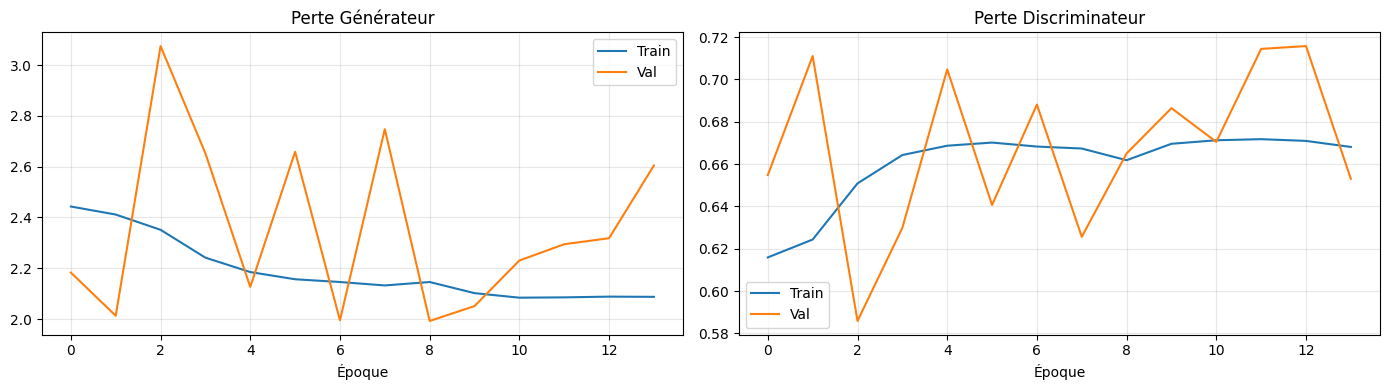

In [11]:
# ✅ CORRECTION : utiliser dec_chans_corrected et NON dec_chans
model   = CGAN(enc_chans, dec_chans_corrected, lr_g=2e-4, lr_d=2e-4, lambda_perc=25.0)
trainer = Trainer(model)

trainer.fit(
    train_loader,
    val_loader,
    epochs  = EPOCHS,
    verbose = True,
    patience= PATIENCE,
)

trainer.plot_history()

/tmp/ipykernel_23/743492190.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


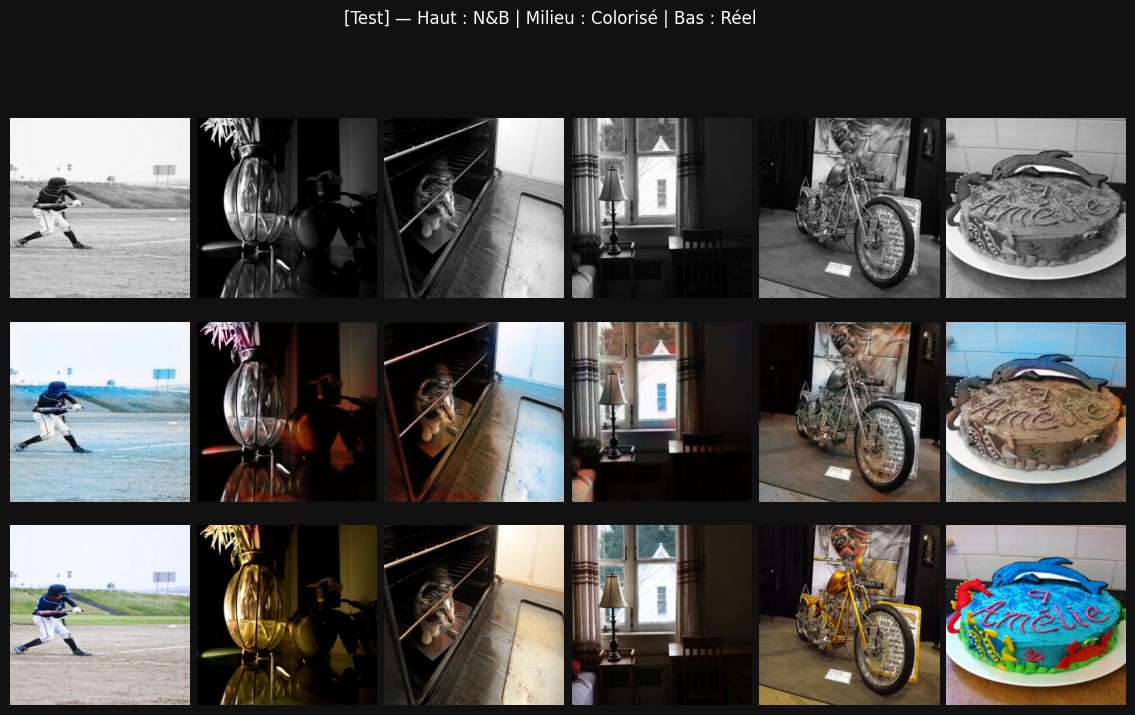

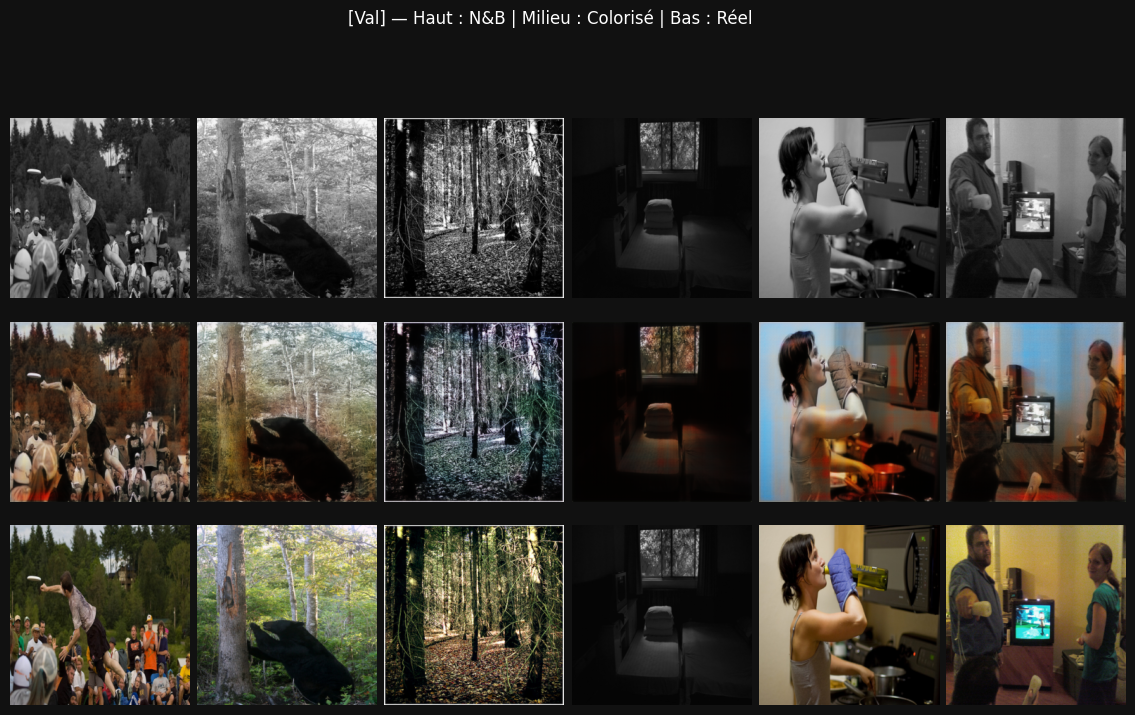

In [12]:
def show_predictions(model, loader, n=6, split="Test"):
    x_batch, y_batch = next(iter(loader))
    n = min(n, x_batch.size(0))
 
    with torch.no_grad():
        pred_batch = model.predict(x_batch[:n])  # (n,3,H,W)
 
    fig, axes = plt.subplots(3, n, figsize=(n * 2.4, 3 * 2.6),
                             gridspec_kw={"hspace": 0.05, "wspace": 0.04})
    fig.patch.set_facecolor("#111111")
    labels = ["N&B (input)", "Colorisé (pred)", "Réel (target)"]
 
    for row, (batch, cmap) in enumerate([
        (x_batch[:n], "gray"),
        (pred_batch,  None),
        (y_batch[:n], None),
    ]):
        for col in range(n):
            ax = axes[row][col]
            img = tensor_to_img(batch[col])
            ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(labels[row], color="white", fontsize=9, labelpad=6)
 
    fig.suptitle(f"[{split}] — Haut : N&B | Milieu : Colorisé | Bas : Réel",
                 color="white", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"predictions_{split.lower()}.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
 
show_predictions(model, test_loader, n=6, split="Test")
show_predictions(model, val_loader,  n=6, split="Val")